# 单孔漏斗爆破：多通道动态 STVMD 分析

本 Notebook 使用 pandas 将Instantel ASCII文件转换为CSV，并逐字嵌入 `main_STVMD.ipynb` 的Numba辅助函数和STVMD类。Tran、Vert、Long均以5m/10m/15m作为三个通道，步长固定为1。

## 1. 参数配置

K、α、时窗长度和最大迭代数可在下方修改。完整原算法不分批，较大的 `MAX_ITERS` 会显著增加中心频率历史数组的内存。

In [18]:
import numpy as np
from numba import jit, prange
import matplotlib.pyplot as plt
import scipy
from scipy.fft import rfft, irfft, fftshift, ifftshift
from tqdm import tqdm

In [19]:
from dataclasses import dataclass
from pathlib import Path
import json
import os
import re
import warnings

import pandas as pd
from IPython.display import display

In [ ]:
K = 4
ALPHA = 50.0
WINDOW_LENGTH = 1024
TAU = 1e-5
TOL = 1e-9
MAX_ITERS = 2000
PLOT_MAX_HZ = 200.0
SAVE_OUTPUTS = True

print(
    f"K={K}, alpha={ALPHA}, window={WINDOW_LENGTH}, "
    f"max_iters={MAX_ITERS}"
)

K=4, alpha=50.0, window=64, max_iters=2000


## 2. 数据读取与校验：pandas转换CSV

三份TXT的数值区转换为 `data_csv/*.csv`，列为 `Sample, Time_s, Tran, Vert, Long`；随后只从CSV组装分析数组。

In [7]:
@dataclass(frozen=True)
class BlastRecord:
    path: Path
    metadata: dict
    fs: float
    pretrigger_seconds: float
    columns: tuple
    data: np.ndarray


def _metadata_number(metadata, key):
    if key not in metadata:
        raise ValueError(f"缺少元数据字段: {key}")
    match = re.search(r"[-+]?\d+(?:\.\d+)?", metadata[key])
    if match is None:
        raise ValueError(f"无法解析元数据字段 {key}: {metadata[key]!r}")
    return float(match.group())


def load_instantel_txt(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"找不到输入文件: {path}")
    lines = path.read_text(encoding="utf-8-sig", errors="replace").splitlines()
    metadata = {}
    header_index = None
    for index, raw in enumerate(lines):
        stripped = raw.strip().strip('"')
        if all(name in stripped for name in ("Tran", "Vert", "Long")):
            header_index = index
            break
        if ":" in stripped:
            key, value = stripped.split(":", 1)
            metadata[key.strip()] = value.strip()
    if header_index is None:
        raise ValueError(f"{path.name}: 未找到 Tran/Vert/Long 数据表头")
    data = np.loadtxt(lines[header_index + 1 :], dtype=float)
    data = np.atleast_2d(data)
    if data.shape[1] != 3:
        raise ValueError(f"{path.name}: 期望3列数据，实际为{data.shape[1]}列")
    if not np.isfinite(data).all():
        raise ValueError(f"{path.name}: 数据包含 NaN 或无穷值")
    fs = _metadata_number(metadata, "Sample Rate")
    pretrigger = abs(_metadata_number(metadata, "Pre-trigger Length"))
    if fs <= 0:
        raise ValueError(f"{path.name}: 采样率必须为正数")
    return BlastRecord(
        path=path,
        metadata=metadata,
        fs=fs,
        pretrigger_seconds=pretrigger,
        columns=("Tran", "Vert", "Long"),
        data=data,
    )


def convert_instantel_ascii_to_csv(txt_path, csv_path):
    txt_path, csv_path = Path(txt_path), Path(csv_path)
    if not txt_path.is_file():
        raise FileNotFoundError(f"找不到输入文件: {txt_path}")
    lines = txt_path.read_text(
        encoding="utf-8-sig", errors="replace"
    ).splitlines()
    metadata, header_index = {}, None
    for index, raw in enumerate(lines):
        stripped = raw.strip().strip('"')
        if all(name in stripped for name in ("Tran", "Vert", "Long")):
            header_index = index
            break
        if ":" in stripped:
            key, value = stripped.split(":", 1)
            metadata[key.strip()] = value.strip()
    if header_index is None:
        raise ValueError(f"{txt_path.name}: 未找到 Tran/Vert/Long 表头")
    fs = _metadata_number(metadata, "Sample Rate")
    pretrigger = abs(_metadata_number(metadata, "Pre-trigger Length"))
    frame = pd.read_csv(
        txt_path,
        sep=r"\s+",
        skiprows=header_index + 1,
        names=["Tran", "Vert", "Long"],
        engine="python",
    )
    if frame.shape[1] != 3 or frame.isna().any().any():
        raise ValueError(f"{txt_path.name}: 数值区不是有效的三列数据")
    frame.insert(
        0, "Time_s", np.arange(len(frame)) / fs - pretrigger
    )
    frame.insert(0, "Sample", np.arange(len(frame), dtype=int))
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(csv_path, index=False)
    return {
        "fs": fs,
        "pretrigger_seconds": pretrigger,
        "metadata": metadata,
    }


def prepare_direction_inputs(records):
    order = ("5m", "10m", "15m")
    missing = [key for key in order if key not in records]
    if missing:
        raise ValueError(f"缺少测点记录: {missing}")
    fs_values = np.array([records[key].fs for key in order], dtype=float)
    pre_values = np.array(
        [records[key].pretrigger_seconds for key in order], dtype=float
    )
    if not np.allclose(fs_values, fs_values[0]):
        raise ValueError(f"采样率不一致: {fs_values.tolist()}")
    if not np.allclose(pre_values, pre_values[0]):
        raise ValueError(f"预触发长度不一致: {pre_values.tolist()}")
    common_n = min(records[key].data.shape[0] for key in order)
    signals = {}
    for column_index, direction in enumerate(("Tran", "Vert", "Long")):
        signals[direction] = np.vstack(
            [records[key].data[:common_n, column_index] for key in order]
        )
    time_s = np.arange(common_n) / fs_values[0] - pre_values[0]
    return signals, time_s


def load_csv_direction_inputs(csv_paths):
    order = ("5m", "10m", "15m")
    required = {"Sample", "Time_s", "Tran", "Vert", "Long"}
    frames = {}
    for key in order:
        if key not in csv_paths:
            raise ValueError(f"缺少CSV路径: {key}")
        frame = pd.read_csv(csv_paths[key])
        if not required.issubset(frame.columns):
            raise ValueError(f"{csv_paths[key]}: CSV列不完整")
        frames[key] = frame
    common_n = min(len(frame) for frame in frames.values())
    signals = {
        direction: np.vstack([
            frames[key][direction].to_numpy(float)[:common_n]
            for key in order
        ])
        for direction in ("Tran", "Vert", "Long")
    }
    time_s = frames["5m"]["Time_s"].to_numpy(float)[:common_n]
    return frames, signals, time_s

In [8]:
DATA_FILES = {
    "5m": Path("5m.TXT"),
    "10m": Path("10m.TXT"),
    "15m": Path("15m.TXT"),
}
CSV_DIR = Path("data_csv")
CSV_PATHS = {
    distance: CSV_DIR / f"{distance}.csv" for distance in DATA_FILES
}
conversion_info = {
    distance: convert_instantel_ascii_to_csv(
        DATA_FILES[distance], CSV_PATHS[distance]
    )
    for distance in DATA_FILES
}
fs_values = [conversion_info[key]["fs"] for key in ("5m", "10m", "15m")]
if not np.allclose(fs_values, fs_values[0]):
    raise ValueError(f"采样率不一致: {fs_values}")
fs = fs_values[0]
frames, signals, time_s = load_csv_direction_inputs(CSV_PATHS)
if QUICK_TEST:
    trigger_index = int(round(
        conversion_info["5m"]["pretrigger_seconds"] * fs
    ))
    quick_start = max(0, trigger_index - 128)
    quick_stop = min(time_s.size, quick_start + 256)
    signals = {
        key: value[:, quick_start:quick_stop] for key, value in signals.items()
    }
    time_s = time_s[quick_start:quick_stop]

print("采样率:", fs, "Hz")
print("共同样本数:", time_s.size)
print("时间范围:", (float(time_s[0]), float(time_s[-1])), "s")
print("频率分辨率:", fs / WINDOW_LENGTH, "Hz")
for distance, frame in frames.items():
    event_time = conversion_info[distance]["metadata"].get("Event Time", "")
    print(distance, frame.shape, event_time, CSV_PATHS[distance])

采样率: 4096.0 Hz
共同样本数: 14336
时间范围: (-0.5, 2.999755859375) s
频率分辨率: 64.0 Hz
5m (33493, 5) 15:41:05 data_csv\5m.csv
10m (14336, 5) 15:41:18 data_csv\10m.csv
15m (23176, 5) 15:40:50 data_csv\15m.csv


## 3. 原仓库动态多通道 STVMD

下面三个标记单元逐字来自 `main_STVMD.ipynb`。Numba仅加速缓冲、反缓冲和窗归一化函数；动态迭代由原NumPy循环执行，`tqdm`显示迭代进度。未使用分批优化。

In [9]:
@jit(nopython=True, cache=True)
def _buffer(x, out, nfft, hop_len):
    for i in prange(0, x.shape[-1]-nfft+1, hop_len):
        out[:,:,i]=x[:,i:i+nfft]
def buffer(x, nfft, hop_len, modulated=True):
    # x: channel, time
    if np.ndim(x)==1:
        x = x.reshape(1,-1)
    out = np.zeros((x.shape[0], nfft, x.shape[-1]-nfft+1))
    _buffer(x, out, nfft, hop_len)
    if modulated:
        out = np.roll(out, int(np.ceil(nfft / 2)), 1)
    return out

@jit(nopython=True, cache=True)
def _unbuffer(x, xbuf, window, hop_len):
    for i in prange(xbuf.shape[2]):
        n = i * hop_len
        x[:, n:n + len(window)] += xbuf[:, :, i] * window
        
def unbuffer(xbuf, window, hop_len, win_exp=1):
    if np.ndim(xbuf)==2:
        xbuf=np.expand_dims(xbuf,0)
    if win_exp == 0:
        window = 1
    elif win_exp != 1:
        window = window ** win_exp
    x = np.zeros((xbuf.shape[0], xbuf.shape[1] + xbuf.shape[2] - 1), dtype=xbuf.dtype)

    _unbuffer(x, xbuf, window, hop_len)
    return x

@jit(nopython=True, cache=True)
def _window_norm(wn, window, hop_len, n_fft, win_exp=1):
    max_hops = (len(wn) - n_fft) // hop_len + 1
    wpow = window ** (win_exp + 1)
    for i in range(max_hops):
        n = i * hop_len
        wn[n:n + n_fft] += wpow

def window_norm(window, hop_len, n_fft, N, win_exp=1):
    wn = np.zeros(N + n_fft - 1)
    _window_norm(wn, window, hop_len, n_fft, win_exp)
    return wn

In [10]:
class STVMD(object):
    def __init__(self, num_channel, n_fft= 128, cache_size=None, window_func=None, alpha= 10, K= 3, init=1, tol=1e-05, tau= 0.1, win_exp=1, maxiters=1000) -> None:
        # n_fft: odd integers
        self.hop_len = 1
        self.n_fft = n_fft
        self.win_len = n_fft
        self.alpha = alpha*np.ones(K)
        self.freqs = np.arange(1, n_fft//2+2)/(n_fft//2+1)
        self.K=K
        self.win_exp = win_exp
        self.init=init
        self.tol=tol
        self.tau=tau
        self.padwidth = ((n_fft-1)//2, (n_fft-1)//2) if (n_fft-1)%2==0 else ((n_fft-1)//2+1, (n_fft-1)//2)
        if window_func is None:
            self.window = scipy.signal.windows.dpss(self.win_len, max(4, self.win_len//8), sym=False)
        else:
            self.window = window_func
        self.maxiters = maxiters

        self.num_channel = num_channel
        
        if cache_size is None:
            self.cache_size = self.n_fft
        else:
            self.cache_size = cache_size
        self.buffer_cache = np.zeros((self.num_channel, self.cache_size))# channel, F, T
        self.u_hat_cache = np.zeros((self.num_channel, len(self.freqs), self.K, self.cache_size)) # C, len(self.freqs), self.K, N
        self.u_hat_plus = None
        self.sum_uk = None
    
    def prepare_online(self, x):
        assert np.ndim(x)<=2
        if np.ndim(x)==1:
            x = x.reshape(-1, 1)
        print(x.shape)
        print(self.buffer_cache.shape)
        new_dims = x.shape[-1]
        self.buffer_cache = np.roll(self.buffer_cache, -new_dims, axis=1)
        self.buffer_cache[:,-new_dims:]=x
        xp = np.pad(self.buffer_cache, ([0, 0], [0, (self.n_fft-1)//2]), mode='reflect')
        print(xp.shape)
        Sx = buffer(xp, self.n_fft, self.hop_len, modulated=False)
        # Sx *= ifftshift(self.window, axes=0).reshape((1, -1, 1))
        Sx *= self.window.reshape((1, -1, 1))
        print(Sx.shape)
        f_hat_plus = rfft(Sx, axis=1, workers=-1)
        return f_hat_plus, Sx
    
    def prepare_offline(self, x):
        assert np.ndim(x)<=2
        if np.ndim(x)==1:
            x = x.reshape(1, -1)
        # assert x.shape[-1]>=self.n_fft
        xp = np.pad(x, ([0, 0], self.padwidth), mode='reflect')
        self.buffer_cache = xp[:, -self.n_fft//2+1-self.n_fft:-self.n_fft//2+1]
        Sx = buffer(xp, self.n_fft, self.hop_len, modulated=False)
        # Sx *= ifftshift(self.window, axes=0).reshape((1, -1, 1))
        Sx *= self.window.reshape((1, -1, 1))
        f_hat_plus = rfft(Sx, axis=1, workers=-1)
        return f_hat_plus, Sx
    
    def apply(self, f_hat_plus, omega=None, dynamic=False):
        if dynamic:
            u_hat, omega = self.apply_dynamic(f_hat_plus)
        else:
            u_hat, omega = self.apply_nodynamic(f_hat_plus, omega)
        return u_hat, omega
    
    def apply_nodynamic(self, f_hat_plus, omega=None, cached=False):
        C, _, N = f_hat_plus.shape
        omega_plus = np.zeros([self.maxiters, self.K])
        if omega is None:
            for i in range(self.K):
                omega_plus[0,i] = (1/self.K)*i
        else:
            omega_plus[0,:] = omega.reshape(-1,1)
        
        if cached:
            u_hat_plus = np.zeros([2, C, len(self.freqs), self.K, N],dtype=complex)
            u_hat_plus[0,:,:,:,:-1]=self.u_hat_cache[:,:,:,1:]
        else:
            u_hat_plus = np.zeros([2, C, len(self.freqs), self.K, N],dtype=complex)
        sum_uk = np.zeros([N, C, len(self.freqs)], dtype=complex)
        lambda_hat = np.zeros([2, C, len(self.freqs), N], dtype = complex)
        
        pbar = tqdm(np.arange(self.maxiters-1))
        for iter in pbar:
            # n = np.mod(iter, 2)
            
            k = 0
            for c in np.arange(C):
                for sw in np.arange(N):
                    sum_uk[sw,c,:] = u_hat_plus[np.mod(iter, 2), c,:,self.K-1,sw] + sum_uk[sw, c,:] - u_hat_plus[np.mod(iter, 2), c,:,0, sw]
                    u_hat_plus[np.mod(iter+1, 2), c,:,k, sw] = (f_hat_plus[c, :, sw] - sum_uk[sw, c,:] - lambda_hat[np.mod(iter, 2), c,:,sw]/2)/(1.+self.alpha[k]*(self.freqs - omega_plus[np.mod(iter, 2),k])**2)
            for k in np.arange(1,self.K):
                for sw in np.arange(N):
                    for c in np.arange(C):
                        #accumulator
                        sum_uk[sw,c,:] = u_hat_plus[np.mod(iter+1, 2),c,:,k-1,sw] + sum_uk[sw,c,:] - u_hat_plus[np.mod(iter, 2),c,:,k,sw]
                        # mode spectrum
                        u_hat_plus[np.mod(iter+1, 2),c,:,k,sw] = (f_hat_plus[c,:,sw] - sum_uk[sw,c,:] - lambda_hat[np.mod(iter, 2),c,:,sw]/2)/(1+self.alpha[k]*(self.freqs - omega_plus[np.mod(iter, 2),k])**2)
                # center frequencies
                if omega is not None:
                    omega_plus[np.mod(iter+1, 2),k] = omega_plus[0,k]
                else:
                    omega_plus[np.mod(iter+1, 2),k] = np.sum(np.einsum('j,ijk', self.freqs,(abs(u_hat_plus[np.mod(iter+1, 2), :, :, k, :])**2)))/np.sum(abs(u_hat_plus[np.mod(iter+1, 2),:,:,k,:])**2)
            lambda_hat[np.mod(iter+1, 2),:,:,:] = lambda_hat[np.mod(iter, 2),:,:,:] + self.tau*(np.sum(u_hat_plus[np.mod(iter+1, 2),:,:,:,:],axis = 2)-f_hat_plus)
            
            uDiff = np.spacing(np.ones((C, N, self.K)))
            for i in range(self.K):
                for c in range(C):
                    for n in range(N):
                        delta = u_hat_plus[0,c,:,i,n]-u_hat_plus[1,c,:,i, n]
                        delta = delta.reshape(-1)
                        uDiff[c,n,i] = (1/len(delta))*np.dot(delta,np.conj(delta)).real
            uDiff = uDiff.mean(-1)
            uDiff = uDiff.max()
            if uDiff < self.tol and iter>2:
                break
            pbar.set_description("Processing "  + "{:10.9f}".format(uDiff) + ":")
        u_hat = u_hat_plus[np.mod(iter, 2)]
        omega = omega_plus[np.mod(iter, 2)]
        self.u_hat_cache = u_hat_plus[np.mod(iter, 2), :, :, :, -self.cache_size:]
        seqw = np.argsort(omega)
        u_hat = u_hat[:,:,seqw,:]
        omega = omega[seqw]
        return u_hat, omega
    
    def apply_dynamic(self, f_hat_plus, cached=False):
        C, F, N = f_hat_plus.shape
        freqs = np.arange(1, F+1)/F# self.freqs
        omega_plus = np.zeros([self.maxiters, self.K, N])
        for i in range(self.K):
            omega_plus[0,i,:] = (1/self.K)*i
            
        if cached:
            u_hat_plus = np.zeros([2, C, len(freqs), self.K, N],dtype=complex)
            u_hat_plus[0,:,:,:,:-1]=self.u_hat_cache[:,:,:,1:]
        else:
            u_hat_plus = np.zeros([2, C, len(freqs), self.K, N],dtype=complex)
        sum_uk = np.zeros([N, C, len(freqs)], dtype=complex)
        lambda_hat = np.zeros([2, C, len(freqs), N], dtype = complex)
        
        pbar = tqdm(np.arange(self.maxiters-1))
        for iter in pbar:
            # n = np.mod(iter, 2)
            
            k = 0
            for c in np.arange(C):
                for sw in np.arange(N):
                    sum_uk[sw,c,:] = u_hat_plus[np.mod(iter, 2), c,:,self.K-1,sw] + sum_uk[sw, c,:] - u_hat_plus[np.mod(iter, 2), c,:,0, sw]
                    u_hat_plus[np.mod(iter+1, 2), c,:,k, sw] = (f_hat_plus[c, :, sw] - sum_uk[sw, c,:] - lambda_hat[np.mod(iter, 2), c,:,sw]/2)/(1.+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k, sw])**2)
            for k in np.arange(1,self.K):
                for sw in np.arange(N):
                    for c in np.arange(C):
                        #accumulator
                        sum_uk[sw,c,:] = u_hat_plus[np.mod(iter+1, 2),c,:,k-1,sw] + sum_uk[sw,c,:] - u_hat_plus[np.mod(iter, 2),c,:,k,sw]
                        # mode spectrum
                        
                        u_hat_plus[np.mod(iter+1, 2),c,:,k,sw] = (f_hat_plus[c,:,sw] - sum_uk[sw,c,:] - lambda_hat[np.mod(iter, 2),c,:,sw]/2)/(1+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k, sw])**2)
                        # center frequencies
                    omega_plus[np.mod(iter+1, 2),k,sw] = np.sum(np.einsum('j,ij', freqs,(abs(u_hat_plus[np.mod(iter+1, 2), :, :, k, sw])**2)))/np.sum(abs(u_hat_plus[np.mod(iter+1, 2),:,:,k,sw])**2)
            lambda_hat[np.mod(iter+1, 2),:,:,:] = lambda_hat[np.mod(iter, 2),:,:,:] + self.tau*(np.sum(u_hat_plus[np.mod(iter+1, 2),:,:,:,:],axis = 2)-f_hat_plus)
            uDiff = np.spacing(np.ones((C, N, self.K)))
            for i in range(self.K):
                for c in range(C):
                    for n in range(N):
                        delta = u_hat_plus[0,c,:,i,n]-u_hat_plus[1,c,:,i, n]
                        delta = delta.reshape(-1)
                        uDiff[c,n,i] = (1/len(delta))*np.dot(delta,np.conj(delta)).real
            uDiff = uDiff.mean(-1)
            uDiff = uDiff.max()
            if uDiff < self.tol and iter>2:
                break
            pbar.set_description("Processing "  + "{:10.9f}".format(uDiff) + ":")
        u_hat = u_hat_plus[np.mod(iter, 2)]
        self.u_hat_cache = u_hat_plus[np.mod(iter, 2), :, :, :, -self.cache_size:]
        omega = omega_plus[np.mod(iter, 2)]
        seqw = np.argsort(omega, axis=0)
        for n in range(N):
            u_hat[:,:,:,n] = u_hat[:,:,seqw[:,n],n]
            omega[:,n] = omega[seqw[:,n],n]
        return u_hat, omega
    
    def postprocess(self, u_hat):
        u = np.zeros([self.K, u_hat.shape[0], u_hat.shape[-1]+np.sum(self.padwidth)])
        wn = window_norm(self.window, self.hop_len, self.n_fft, u_hat.shape[-1], self.win_exp)
        for k in range(self.K):
            xbuf = irfft(u_hat[:,:,k,:], n=self.n_fft, axis=1, workers=-1).real
            # xbuf = fftshift(xbuf, axes=0)
            u[k,:,:] = unbuffer(xbuf, self.window, self.hop_len, self.win_exp)
        u = u/wn.reshape(1,1,-1)

        u = u[:, :, self.padwidth[0]:-self.padwidth[1]]
        return u

In [11]:
def estimate_original_stvmd_memory_gb(
    channels, samples, K, window_length, max_iters
):
    freq_bins = window_length // 2 + 1
    complex_bytes = 16
    float_bytes = 8
    u_bytes = 2 * channels * freq_bins * K * samples * complex_bytes
    lambda_bytes = 2 * channels * freq_bins * samples * complex_bytes
    omega_bytes = max_iters * K * samples * float_bytes
    return (u_bytes + lambda_bytes + omega_bytes) / (1024 ** 3)


def run_original_stvmd(
    x, fs, K=4, alpha=50.0, window_length=64,
    tau=1e-5, tol=1e-9, max_iters=2000,
):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2 or not np.isfinite(x).all():
        raise ValueError("输入必须为有限的 (通道, 时间) 二维数组")
    window = scipy.signal.windows.hamming(window_length, sym=False)
    model = STVMD(
        num_channel=x.shape[0],
        window_func=window,
        alpha=alpha,
        n_fft=window_length,
        K=K,
        tol=tol,
        tau=tau,
        maxiters=max_iters,
    )
    f_hat_s, windowed = model.prepare_offline(x)
    u_hat, omega = model.apply(f_hat_s, dynamic=True)
    modes = model.postprocess(u_hat)
    return {
        "modes": modes,
        "u_hat": u_hat,
        "center_freq_hz": omega * (fs / 2.0),
        "mean_tf_power": np.mean(np.abs(f_hat_s) ** 2, axis=0),
        "windowed_signal": windowed,
    }

In [12]:
def power_to_db(power, floor_db=-100.0):
    power = np.asarray(power, dtype=float)
    peak = float(np.max(power))
    if not np.isfinite(peak) or peak <= 0:
        return np.full_like(power, floor_db)
    db = 10.0 * np.log10(
        np.maximum(power / peak, 10 ** (floor_db / 10))
    )
    return np.maximum(db, floor_db)


def _energy_band(freq_hz, power, low=0.05, high=0.95):
    power = np.maximum(np.asarray(power, dtype=float), 0.0)
    total = float(np.sum(power))
    if total <= np.finfo(float).eps:
        return np.array([0.0, 0.0])
    cumulative = np.cumsum(power) / total
    return np.array(
        [
            np.interp(low, cumulative, freq_hz),
            np.interp(high, cumulative, freq_hz),
        ]
    )


def summarize_stvmd_result(x, fs, raw_result):
    modes = raw_result["modes"]
    reconstruction = np.sum(modes, axis=0)
    denominator = np.linalg.norm(x, axis=1)
    nrmse = np.divide(
        np.linalg.norm(x - reconstruction, axis=1),
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > np.finfo(float).eps,
    )
    mode_energy = np.sum(modes ** 2, axis=2)
    channel_energy = np.sum(mode_energy, axis=0, keepdims=True)
    energy_fraction = np.divide(
        mode_energy,
        channel_energy,
        out=np.zeros_like(mode_energy),
        where=channel_energy > np.finfo(float).eps,
    )
    freq_hz = scipy.fft.rfftfreq(modes.shape[-1], d=1.0 / fs)
    bands = np.zeros((modes.shape[0], 2), dtype=float)
    mode_power = np.zeros((modes.shape[0], freq_hz.size), dtype=float)
    for mode in range(modes.shape[0]):
        spectra = scipy.fft.rfft(modes[mode], axis=1, workers=-1)
        mode_power[mode] = np.sum(np.abs(spectra) ** 2, axis=0)
        bands[mode] = _energy_band(freq_hz, mode_power[mode])
    result = dict(raw_result)
    result.update(
        {
            "reconstruction": reconstruction,
            "nrmse": nrmse,
            "energy_fraction": energy_fraction,
            "frequency_hz": freq_hz,
            "mode_power": mode_power,
            "frequency_bands_hz": bands,
        }
    )
    return result

In [13]:
DISTANCE_LABELS = ("5 m", "10 m", "15 m")
MODE_COLORS = ("#64748b", "#0072B2", "#D55E00", "#009E73", "#CC79A7")


def _frequency_extent(time_s, fs, frequency_bins):
    return [time_s[0], time_s[-1], 0.0, fs / 2.0]


def _limit_frequency_axis(axis, plot_max_hz, fs):
    axis.set_ylim(0.0, min(float(plot_max_hz), fs / 2.0))
    axis.set_ylabel("Frequency (Hz)")


def plot_input_and_tf(direction, x, time_s, fs, result, plot_max_hz):
    fig, axes = plt.subplots(
        1, 2, figsize=(12, 4.2), constrained_layout=True
    )
    for channel, label in enumerate(DISTANCE_LABELS):
        axes[0].plot(time_s, x[channel], lw=0.8, label=label)
    axes[0].axvline(0, color="black", ls="--", lw=0.8)
    axes[0].set(
        xlabel="Time (s)",
        ylabel="Velocity (mm/s)",
        title=f"{direction}: input velocity",
    )
    axes[0].legend(frameon=False)
    image = axes[1].imshow(
        power_to_db(result["mean_tf_power"]),
        origin="lower",
        aspect="auto",
        extent=_frequency_extent(
            time_s, fs, result["mean_tf_power"].shape[0]
        ),
        cmap="viridis",
        vmin=-80,
        vmax=0,
    )
    _limit_frequency_axis(axes[1], plot_max_hz, fs)
    axes[1].set(xlabel="Time (s)", title="Mean multichannel TF power")
    fig.colorbar(image, ax=axes[1], label="Relative power (dB)")
    return fig


def plot_modes(direction, time_s, result):
    modes = result["modes"]
    mode_n, channel_n, _ = modes.shape
    fig, axes = plt.subplots(
        mode_n,
        channel_n,
        figsize=(12, max(4.0, 2.1 * mode_n)),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )
    for mode in range(mode_n):
        row_name = "Residual" if mode == 0 else f"Mode {mode}"
        for channel in range(channel_n):
            axis = axes[mode, channel]
            axis.plot(
                time_s,
                modes[mode, channel],
                color=MODE_COLORS[mode],
                lw=0.7,
            )
            axis.axvline(0, color="black", ls="--", lw=0.6)
            if mode == 0:
                axis.set_title(DISTANCE_LABELS[channel])
            if channel == 0:
                axis.set_ylabel(f"{row_name}\nVelocity (mm/s)")
            if mode == mode_n - 1:
                axis.set_xlabel("Time (s)")
    fig.suptitle(f"{direction}: dynamic STVMD modes")
    return fig


def plot_if_and_reconstruction(
    direction, x, time_s, result, plot_max_hz
):
    mode_n, channel_n, _ = result["modes"].shape
    fig = plt.figure(figsize=(12, 9), constrained_layout=True)
    grid = fig.add_gridspec(3, 3, height_ratios=(1.0, 1.3, 0.8))
    axis_if = fig.add_subplot(grid[0, :])
    for mode in range(1, mode_n):
        axis_if.plot(
            time_s,
            result["center_freq_hz"][mode],
            color=MODE_COLORS[mode],
            lw=1.1,
            label=f"Mode {mode}",
        )
    axis_if.axvline(0, color="black", ls="--", lw=0.7)
    axis_if.set(
        xlabel="Time (s)",
        ylabel="Frequency (Hz)",
        title=f"{direction}: instantaneous center frequencies",
        ylim=(0.0, plot_max_hz),
    )
    axis_if.legend(frameon=False, ncol=max(1, mode_n - 1))

    for channel in range(channel_n):
        axis = fig.add_subplot(grid[1, channel])
        axis.plot(
            time_s, x[channel], color="#64748b", lw=0.8, label="Input"
        )
        axis.plot(
            time_s,
            result["reconstruction"][channel],
            color="#D55E00",
            lw=0.7,
            alpha=0.85,
            label="Reconstruction",
        )
        axis.axvline(0, color="black", ls="--", lw=0.6)
        axis.set(
            xlabel="Time (s)",
            ylabel="Velocity (mm/s)",
            title=(
                f"{DISTANCE_LABELS[channel]}  "
                f"NRMSE={result['nrmse'][channel]:.3g}"
            ),
        )
        if channel == 0:
            axis.legend(frameon=False)

    axis_energy = fig.add_subplot(grid[2, :])
    energy_image = axis_energy.imshow(
        result["energy_fraction"],
        aspect="auto",
        cmap="magma",
        vmin=0.0,
        vmax=max(1e-12, float(result["energy_fraction"].max())),
    )
    axis_energy.set(
        xlabel="Channel", ylabel="Component", title="Mode energy fraction"
    )
    axis_energy.set_xticks(range(channel_n), DISTANCE_LABELS[:channel_n])
    axis_energy.set_yticks(
        range(mode_n),
        ["Residual"] + [f"Mode {mode}" for mode in range(1, mode_n)],
    )
    fig.colorbar(energy_image, ax=axis_energy, label="Fraction")
    return fig


def plot_spectrum_if_mapping(
    direction, x, time_s, fs, result, plot_max_hz
):
    freq_hz = scipy.fft.rfftfreq(x.shape[1], d=1.0 / fs)
    spectra = scipy.fft.rfft(x, axis=1, workers=-1)
    combined_amplitude = np.sqrt(np.mean(np.abs(spectra) ** 2, axis=0))
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5.2),
        gridspec_kw={"width_ratios": (1.0, 3.2)},
        sharey=True,
        constrained_layout=True,
    )
    axes[0].plot(combined_amplitude, freq_hz, color="#475569", lw=0.8)
    axes[0].set(
        xlabel="Combined amplitude",
        ylabel="Frequency (Hz)",
        title="Fourier spectrum",
    )
    tf_image = axes[1].imshow(
        power_to_db(result["mean_tf_power"]),
        origin="lower",
        aspect="auto",
        extent=_frequency_extent(
            time_s, fs, result["mean_tf_power"].shape[0]
        ),
        cmap="viridis",
        vmin=-80,
        vmax=0,
    )
    for mode in range(1, result["modes"].shape[0]):
        color = MODE_COLORS[mode]
        band_low, band_high = result["frequency_bands_hz"][mode]
        axes[1].plot(
            time_s,
            result["center_freq_hz"][mode],
            color=color,
            lw=1.2,
            label=(
                f"Mode {mode}: {band_low:.1f}-{band_high:.1f} Hz"
            ),
        )
        for boundary in (band_low, band_high):
            axes[0].axhline(boundary, color=color, ls="--", lw=0.8)
            axes[1].axhline(boundary, color=color, ls="--", lw=0.8)
    axes[1].axvline(0, color="white", ls=":", lw=0.8)
    axes[1].set(
        xlabel="Time (s)", title=f"{direction}: TF spectrum and IF tracks"
    )
    axes[1].legend(frameon=True, fontsize=8, loc="upper right")
    _limit_frequency_axis(axes[0], plot_max_hz, fs)
    _limit_frequency_axis(axes[1], plot_max_hz, fs)
    fig.colorbar(tf_image, ax=axes[1], label="Relative power (dB)")
    return fig

In [14]:
def save_direction_figures(output_dir, direction, figures):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = direction.lower()
    for name, figure in figures.items():
        figure.savefig(
            output_dir / f"{prefix}_{name}.png",
            dpi=300,
            bbox_inches="tight",
        )


def save_all_results(output_dir, results, config):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    arrays = {"config_json": json.dumps(config, ensure_ascii=False)}
    for direction, result in results.items():
        prefix = direction.lower()
        for key in (
            "modes",
            "center_freq_hz",
            "reconstruction",
            "nrmse",
            "energy_fraction",
            "frequency_bands_hz",
        ):
            arrays[f"{prefix}_{key}"] = result[key]
    np.savez_compressed(output_dir / "stvmd_results.npz", **arrays)

In [15]:
def analyze_direction(direction, x, time_s, fs):
    raw = run_original_stvmd(
        x,
        fs=fs,
        K=K,
        alpha=ALPHA,
        window_length=WINDOW_LENGTH,
        tau=TAU,
        tol=TOL,
        max_iters=MAX_ITERS,
    )
    result = summarize_stvmd_result(x, fs, raw)
    figures = {
        "input_tf": plot_input_and_tf(
            direction, x, time_s, fs, result, PLOT_MAX_HZ
        ),
        "modes": plot_modes(direction, time_s, result),
        "if_reconstruction": plot_if_and_reconstruction(
            direction, x, time_s, result, PLOT_MAX_HZ
        ),
        "spectrum_if_mapping": plot_spectrum_if_mapping(
            direction, x, time_s, fs, result, PLOT_MAX_HZ
        ),
    }
    for figure in figures.values():
        display(figure)
    return result, figures

In [16]:
estimated_memory_gb = estimate_original_stvmd_memory_gb(
    3, time_s.size, K, WINDOW_LENGTH, MAX_ITERS
)
print(f"原算法粗略内存估算: {estimated_memory_gb:.2f} GB")
print("说明：原仓库算法一次处理全部滑窗，不使用分批优化。")

原算法粗略内存估算: 1.07 GB
说明：原仓库算法一次处理全部滑窗，不使用分批优化。


## 4. Tran 方向

Processing 0.000001453:: 100%|██████████| 1999/1999 [2:29:57<00:00,  4.50s/it]  


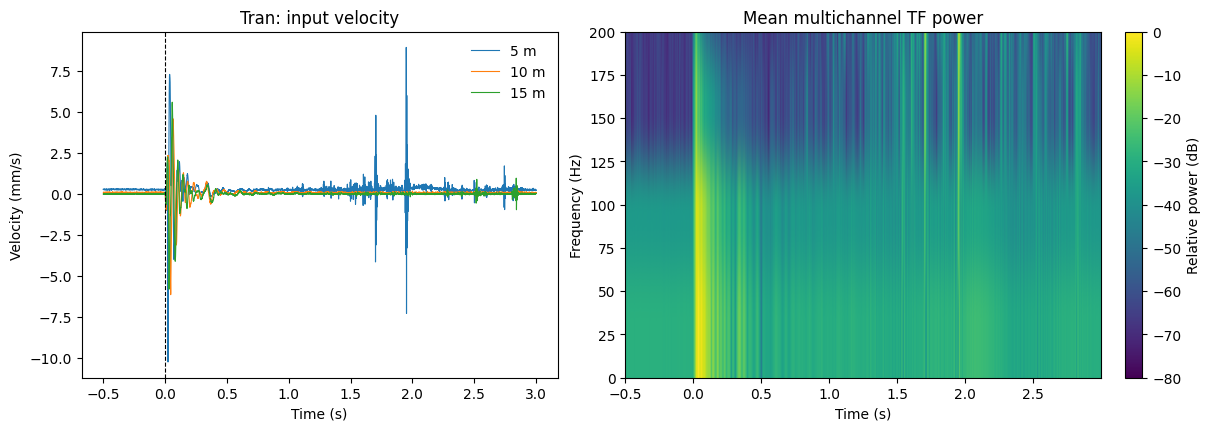

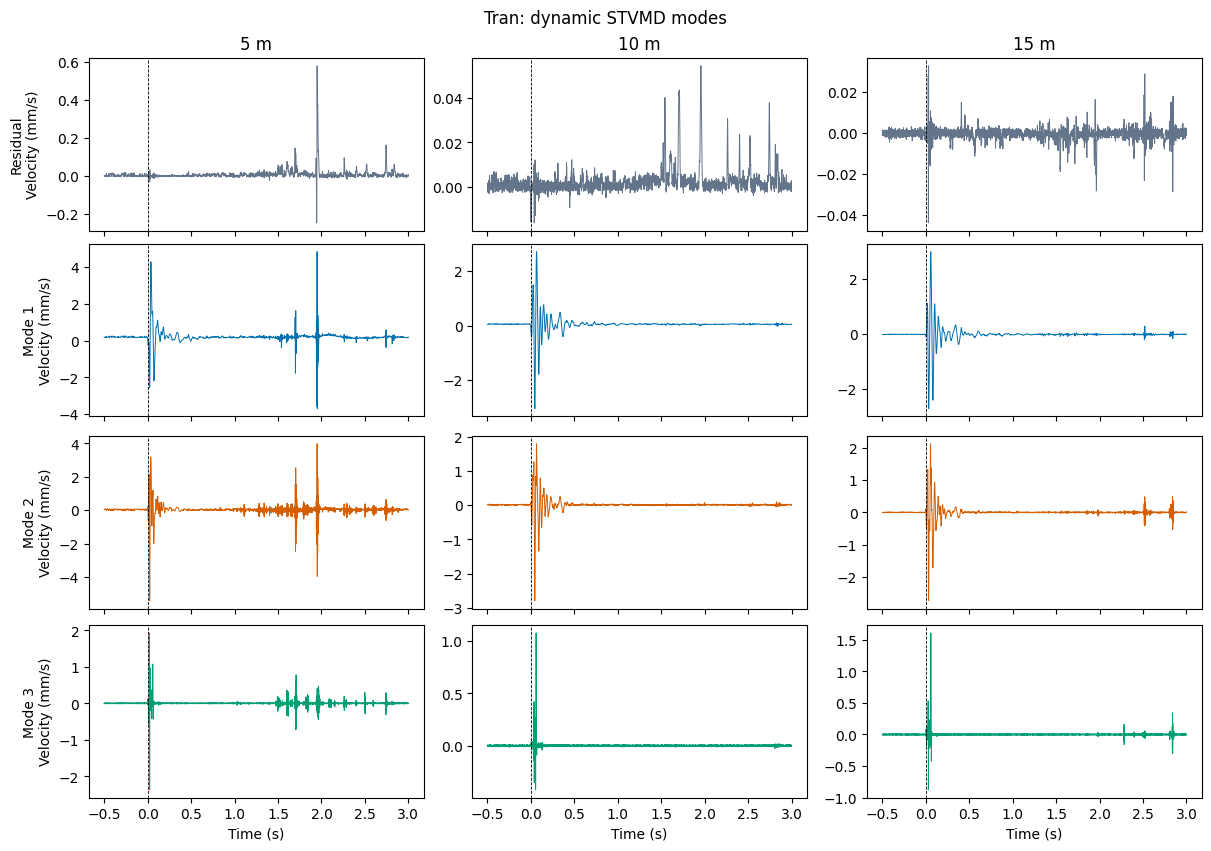

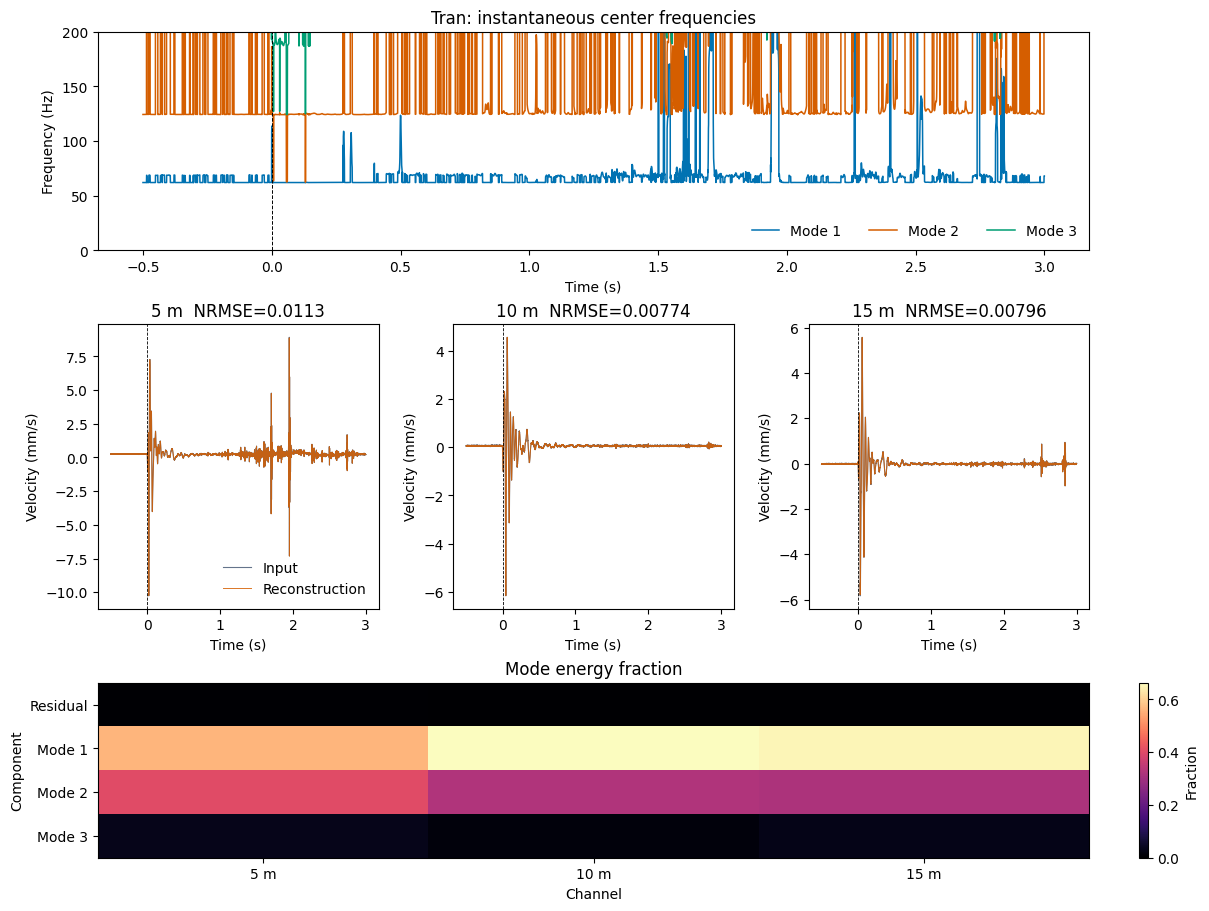

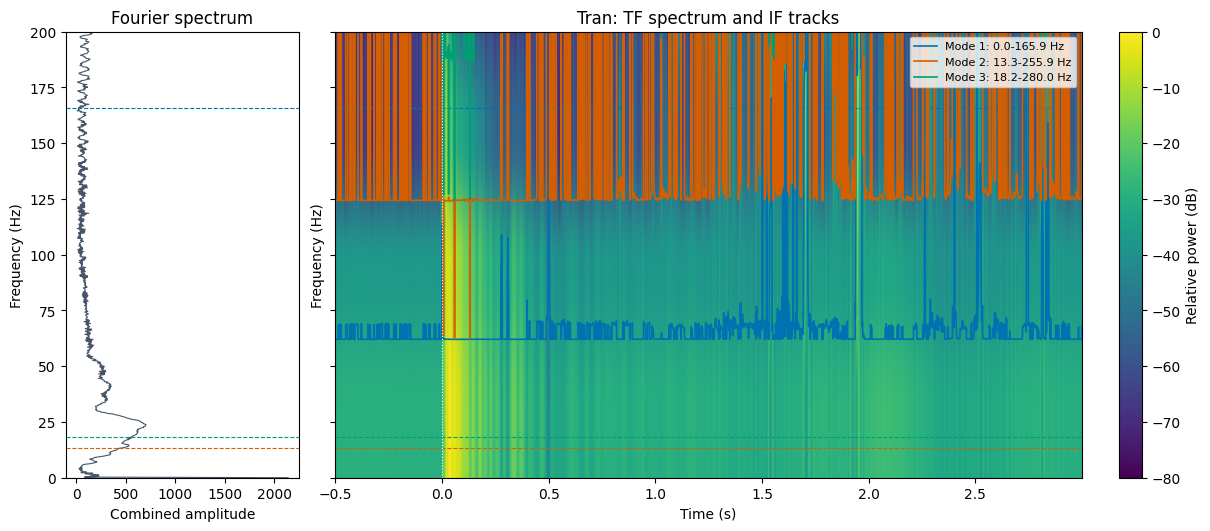

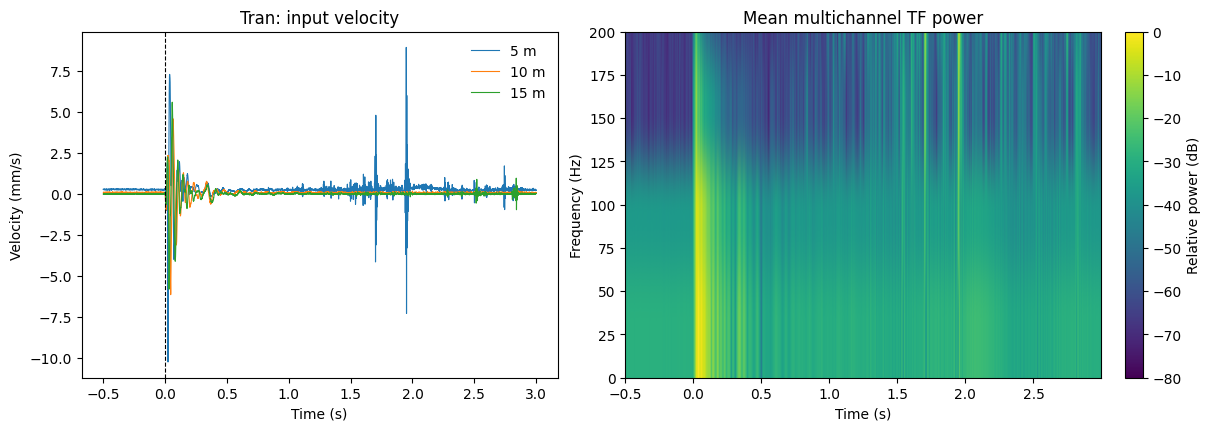

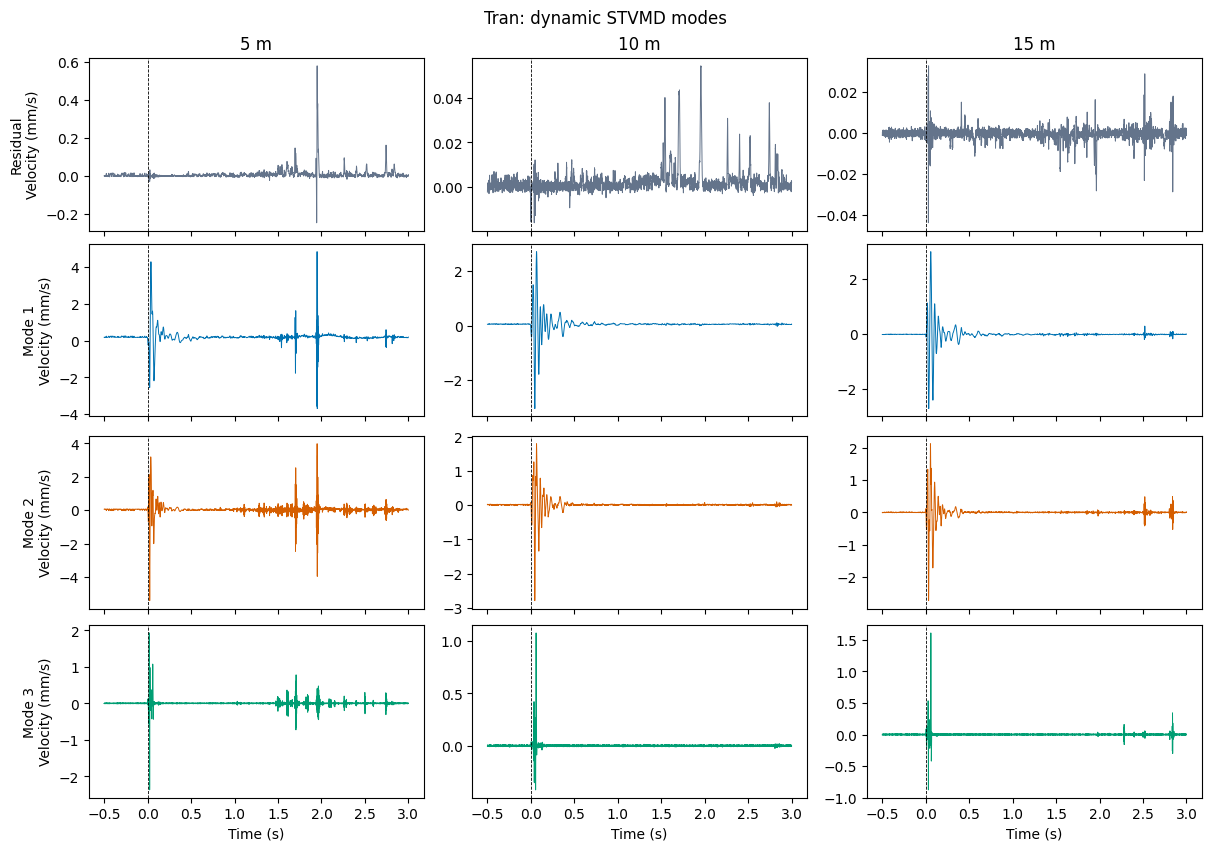

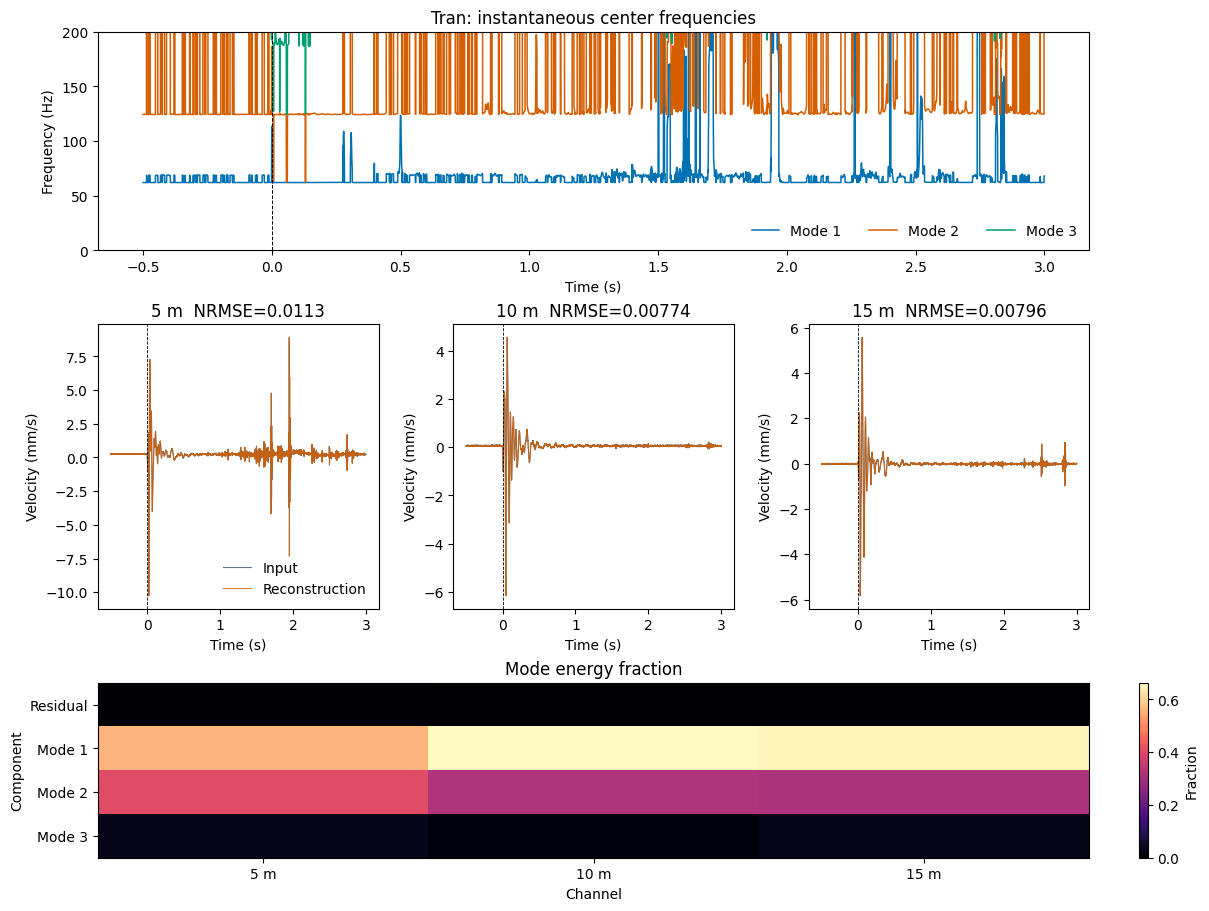

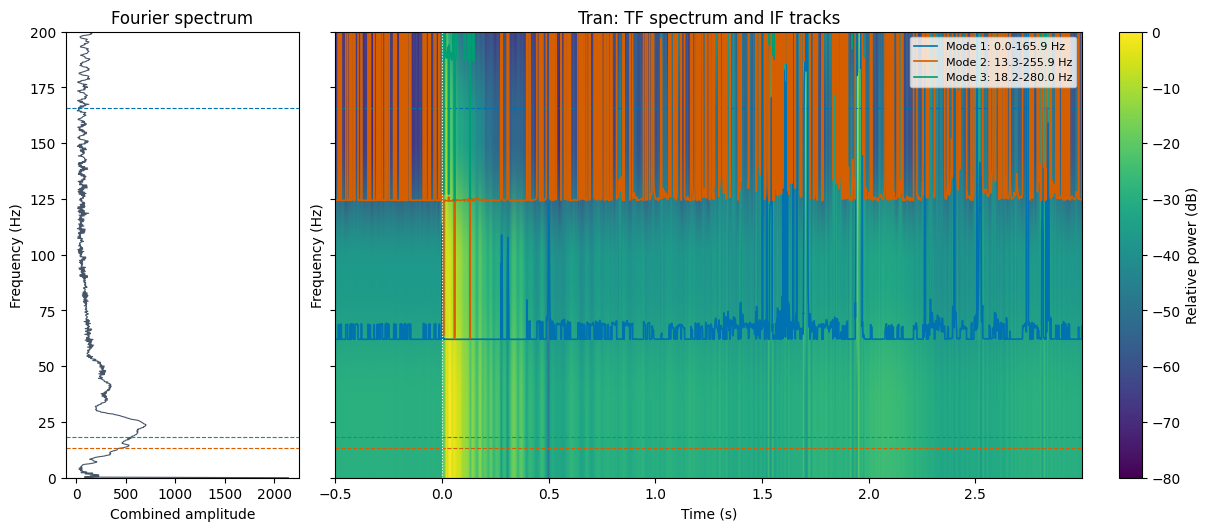

In [17]:
results = {}
figures_by_direction = {}
results["Tran"], figures_by_direction["Tran"] = analyze_direction(
    "Tran", signals["Tran"], time_s, fs
)

## 5. Vert 方向

In [ ]:
results["Vert"], figures_by_direction["Vert"] = analyze_direction(
    "Vert", signals["Vert"], time_s, fs
)

## 6. Long 方向

In [ ]:
results["Long"], figures_by_direction["Long"] = analyze_direction(
    "Long", signals["Long"], time_s, fs
)

## 7. 结果保存

In [ ]:
OUTPUT_DIR = Path("output/stvmd_blast")
CONFIG_SNAPSHOT = {
    "K": K, "ALPHA": ALPHA, "WINDOW_LENGTH": WINDOW_LENGTH,
    "TAU": TAU, "TOL": TOL, "MAX_ITERS": MAX_ITERS,
    "PLOT_MAX_HZ": PLOT_MAX_HZ,
}
if SAVE_OUTPUTS:
    for direction, direction_figures in figures_by_direction.items():
        save_direction_figures(OUTPUT_DIR, direction, direction_figures)
    save_all_results(OUTPUT_DIR, results, CONFIG_SNAPSHOT)
    print(f"结果已保存到: {OUTPUT_DIR.resolve()}")
else:
    print("SAVE_OUTPUTS=False：未写出结果文件。")